In [206]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [207]:
df = pd.read_csv('../0.Dataset/titanic_kotor_1000.csv')
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,193,1,2,"Johnson, Mr./Mrs. Laina",female,NaN,2,0,PC 61897,14.6663,E46,S
1,540,0,3,"Futrelle, Mr./Mrs. Elizabeth",female,NaN,0,0,PC 45221,241.1648,NaN,S
2,122,1,3,"Allen, Mr./Mrs. Gosta",male,1.0,0,0,309144,7.7993,NaN,S
3,810,0,1,"Johnson, Mr./Mrs. Florence",female,8.0,1,0,PC 32983,18.6753,NaN,S
4,326,1,2,"Smith, Mr./Mrs. Laina",MALE,13.0,0,1,PC 22255,39.5465,NaN,Q


In [208]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1020 non-null   int64  
 1   Survived     1020 non-null   int64  
 2   Pclass       1020 non-null   int64  
 3   Name         1020 non-null   object 
 4   Sex          1020 non-null   object 
 5   Age          867 non-null    float64
 6   SibSp        1020 non-null   int64  
 7   Parch        1020 non-null   int64  
 8   Ticket       1020 non-null   object 
 9   Fare         1020 non-null   object 
 10  Cabin        258 non-null    object 
 11  Embarked     1000 non-null   object 
dtypes: float64(1), int64(5), object(6)
memory usage: 95.8+ KB


In [209]:
df.shape

(1020, 12)

In [210]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            153
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          762
Embarked        20
dtype: int64

In [211]:
df.duplicated().sum()

np.int64(20)

In [212]:
df = df.drop(columns='PassengerId')
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,2,"Johnson, Mr./Mrs. Laina",female,NaN,2,0,PC 61897,14.6663,E46,S
1,0,3,"Futrelle, Mr./Mrs. Elizabeth",female,NaN,0,0,PC 45221,241.1648,NaN,S
2,1,3,"Allen, Mr./Mrs. Gosta",male,1.0,0,0,309144,7.7993,NaN,S
3,0,1,"Johnson, Mr./Mrs. Florence",female,8.0,1,0,PC 32983,18.6753,NaN,S
4,1,2,"Smith, Mr./Mrs. Laina",MALE,13.0,0,1,PC 22255,39.5465,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...
1015,1,3,"Johnson, Mr./Mrs. Laina",male,62.0,0,0,551533,90.6072,B145,S
1016,0,3,"McCarthy, Mr./Mrs. Florence",female,40.0,0,1,PC 50723,10.815,NaN,S
1017,0,3,"Heikkinen, Mr./Mrs. Florence",female,17.0,0,0,453487,39.084,NaN,S
1018,0,1,"Cumings, Mr./Mrs. Owen",MALE,6.0,0,0,769191,8.3612,NaN,s


In [213]:
for col in df.columns:
    print(f"Nilai Unik di Kolom {col}")
    print(df[col].unique())
    print("-"*30)

Nilai Unik di Kolom Survived
[1 0]
------------------------------
Nilai Unik di Kolom Pclass
[2 3 1]
------------------------------
Nilai Unik di Kolom Name
['Johnson, Mr./Mrs. Laina' 'Futrelle, Mr./Mrs. Elizabeth'
 'Allen, Mr./Mrs. Gosta' 'Johnson, Mr./Mrs. Florence'
 'Smith, Mr./Mrs. Laina' 'Cumings, Mr./Mrs. James'
 'Cumings, Mr./Mrs. Owen' 'Allen, Mr./Mrs. Florence'
 'Moran, Mr./Mrs. Edward' 'Smith, Mr./Mrs. Lily'
 'Futrelle, Mr./Mrs. William' 'McCarthy, Mr./Mrs. William'
 'Allen, Mr./Mrs. Edward' 'Johnson, Mr./Mrs. Lily'
 'Johnson, Mr./Mrs. James' 'Palsson, Mr./Mrs. Florence'
 'Braund, Mr./Mrs. Edward' 'Smith, Mr./Mrs. Timothy'
 'Braund, Mr./Mrs. Florence' 'McCarthy, Mr./Mrs. Edward'
 'Braund, Mr./Mrs. Elizabeth' 'Braund, Mr./Mrs. Gosta'
 'Futrelle, Mr./Mrs. Timothy' 'Palsson, Mr./Mrs. Gosta'
 'Heikkinen, Mr./Mrs. Elizabeth' 'Johnson, Mr./Mrs. Edward'
 'Heikkinen, Mr./Mrs. William' 'Cumings, Mr./Mrs. William'
 'Moran, Mr./Mrs. Elizabeth' 'Futrelle, Mr./Mrs. Florence'
 'Heikkinen, 

In [214]:
df['Sex'] = df['Sex'].str.upper()
df['Sex'].unique()

array(['FEMALE', 'MALE'], dtype=object)

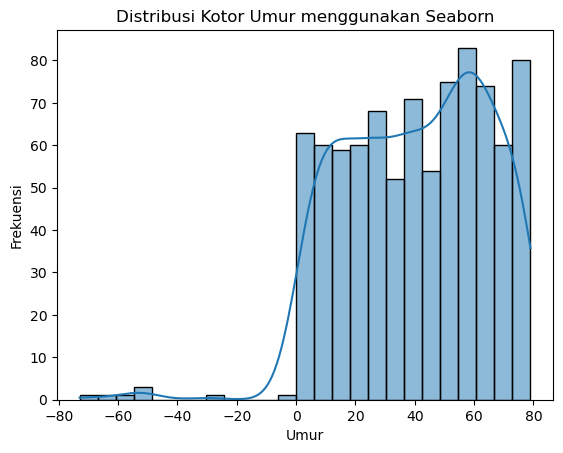

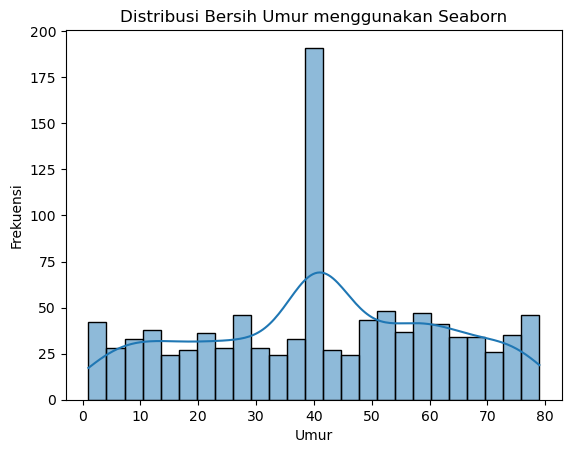

In [215]:
sns.histplot(data=df,x='Age',bins=25,kde=True)
plt.title('Distribusi Kotor Umur menggunakan Seaborn')
plt.xlabel('Umur')
plt.ylabel('Frekuensi')
plt.show()

df['Age'] = df['Age'].abs()
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Age'] = df['Age'].astype('int64')

sns.histplot(data=df,x='Age',bins=25,kde=True)
plt.title('Distribusi Bersih Umur menggunakan Seaborn')
plt.xlabel('Umur')
plt.ylabel('Frekuensi')
plt.show()

In [216]:
df.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age           0
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       762
Embarked     20
dtype: int64

In [217]:
df['Cabin'] = df['Cabin'].fillna(df['Cabin'].mode()[0])
df['Cabin'].isnull().sum()


np.int64(0)

In [ ]:
df['Embarked'] = df['Embarked'].str.upper()
kamus_pelabuhan = {
    'S': 'Southampton',
    'C': 'Cherbourg',
    'Q': 'Queenstown'
}
df['Embarked'] = df['Embarked'].replace(kamus_pelabuhan)

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Embarked'].isnull().sum()

np.int64(0)

In [221]:
df.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Cabin       0
Embarked    0
dtype: int64

In [224]:
df['Embarked'].unique()

array(['Southampton', 'Queenstown', 'Cherbourg'], dtype=object)